# Final TCN Evaluation

This notebook evaluates the trained AAPL Temporal Convolutional
Network on the completely unseen test dataset.

The model architecture is reconstructed exactly as defined during
training in `04_tcn_model.ipynb`.

No training or parameter tuning is performed in this notebook.

The evaluation includes:

- Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- Majority-class baseline comparison
- Prediction confidence analysis

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("PyTorch:", torch.__version__)

NumPy: 2.5.2
Pandas: 3.0.5
PyTorch: 2.13.0


In [2]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

print("Device:", device)

Device: mps


In [3]:
class TCNBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size,
        dilation,
        dropout=0.2
    ):
        super().__init__()

        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size,
            padding=padding,
            dilation=dilation
        )

        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size,
            padding=padding,
            dilation=dilation
        )

        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.residual = (
            nn.Conv1d(
                in_channels,
                out_channels,
                kernel_size=1
            )
            if in_channels != out_channels
            else nn.Identity()
        )

    def forward(self, x):
        residual = self.residual(x)

        x = self.conv1(x)

        x = x[:, :, :residual.size(2)]

        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.conv2(x)

        x = x[:, :, :residual.size(2)]

        x = self.relu2(x)
        x = self.dropout2(x)

        return x + residual

In [4]:
class AAPLTCN(nn.Module):
    def __init__(
        self,
        num_features=9,
        num_classes=2
    ):
        super().__init__()

        self.tcn = nn.Sequential(

            TCNBlock(
                in_channels=num_features,
                out_channels=32,
                kernel_size=3,
                dilation=1
            ),

            TCNBlock(
                in_channels=32,
                out_channels=32,
                kernel_size=3,
                dilation=2
            )
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):

        x = self.tcn(x)

        x = self.classifier(x)

        return x

In [5]:
X_train = np.load(
    "../data/processed/X_train_scaled.npy"
)

X_val = np.load(
    "../data/processed/X_val_scaled.npy"
)

X_test = np.load(
    "../data/processed/X_test_scaled.npy"
)

y_train = np.load(
    "../data/processed/y_train.npy"
)

y_val = np.load(
    "../data/processed/y_val.npy"
)

y_test = np.load(
    "../data/processed/y_test.npy"
)

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [6]:
print("=" * 50)
print("DATASET SHAPES")
print("=" * 50)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

DATASET SHAPES
X_train: (120, 22, 9)
y_train: (120,)
X_val: (40, 22, 9)
y_val: (40,)
X_test: (40, 22, 9)
y_test: (40,)


In [7]:
dates = pd.read_csv(
    "../data/processed/sample_dates.csv",
    index_col=0,
    parse_dates=True
).iloc[:, 0]

dates_test = dates.iloc[-len(y_test):].reset_index(
    drop=True
)

print("Test dates:", len(dates_test))
print(
    dates_test.iloc[0],
    "→",
    dates_test.iloc[-1]
)

Test dates: 40
2026-06-16 → 2026-08-12


In [8]:
model = AAPLTCN(
    num_features=9,
    num_classes=2
).to(device)

print(model)

AAPLTCN(
  (tcn): Sequential(
    (0): TCNBlock(
      (conv1): Conv1d(9, 32, kernel_size=(3,), stride=(1,), padding=(2,))
      (relu1): ReLU()
      (dropout1): Dropout(p=0.2, inplace=False)
      (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(2,))
      (relu2): ReLU()
      (dropout2): Dropout(p=0.2, inplace=False)
      (residual): Conv1d(9, 32, kernel_size=(1,), stride=(1,))
    )
    (1): TCNBlock(
      (conv1): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (relu1): ReLU()
      (dropout1): Dropout(p=0.2, inplace=False)
      (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (relu2): ReLU()
      (dropout2): Dropout(p=0.2, inplace=False)
      (residual): Identity()
    )
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool1d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [9]:
model_path = "../models/aapl_tcn.pt"

model.load_state_dict(
    torch.load(
        model_path,
        map_location=device,
        weights_only=True
    )
)

model.eval()

print("Trained TCN loaded successfully.")
print("Model path:", model_path)

Trained TCN loaded successfully.
Model path: ../models/aapl_tcn.pt


In [10]:
X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
).permute(0, 2, 1)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

print("X_test tensor:", X_test_tensor.shape)
print("y_test tensor:", y_test_tensor.shape)

X_test tensor: torch.Size([40, 9, 22])
y_test tensor: torch.Size([40])


In [11]:
model.eval()

with torch.no_grad():

    logits = model(
        X_test_tensor
    )

    probabilities = torch.softmax(
        logits,
        dim=1
    )

    predictions = torch.argmax(
        probabilities,
        dim=1
    )

y_true = y_test_tensor.cpu().numpy()

y_pred = predictions.cpu().numpy()

test_probabilities = (
    probabilities
    .cpu()
    .numpy()
)

print("Predictions generated.")

print("True shape:", y_true.shape)
print("Prediction shape:", y_pred.shape)
print("Probability shape:", test_probabilities.shape)

Predictions generated.
True shape: (40,)
Prediction shape: (40,)
Probability shape: (40, 2)


In [12]:
print("Class mapping:")
print("0 = Fall")
print("1 = Rise")

print("\nActual test distribution:")

for label, count in zip(
    *np.unique(y_true, return_counts=True)
):
    name = "Fall" if label == 0 else "Rise"
    print(f"{name}: {count}")

print("\nPredicted distribution:")

for label, count in zip(
    *np.unique(y_pred, return_counts=True)
):
    name = "Fall" if label == 0 else "Rise"
    print(f"{name}: {count}")

Class mapping:
0 = Fall
1 = Rise

Actual test distribution:
Fall: 18
Rise: 22

Predicted distribution:
Fall: 40


In [13]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

In [14]:
print("=" * 60)
print("FINAL TCN TEST RESULTS")
print("=" * 60)

print(f"Accuracy:          {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"Recall:            {recall:.4f}")
print(f"F1 Score:          {f1:.4f}")

FINAL TCN TEST RESULTS
Accuracy:          0.4500
Balanced Accuracy: 0.5000
Precision:         0.0000
Recall:            0.0000
F1 Score:          0.0000


In [15]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Fall",
            "Rise"
        ],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        Fall     0.4500    1.0000    0.6207        18
        Rise     0.0000    0.0000    0.0000        22

    accuracy                         0.4500        40
   macro avg     0.2250    0.5000    0.3103        40
weighted avg     0.2025    0.4500    0.2793        40



In [16]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[18  0]
 [22  0]]


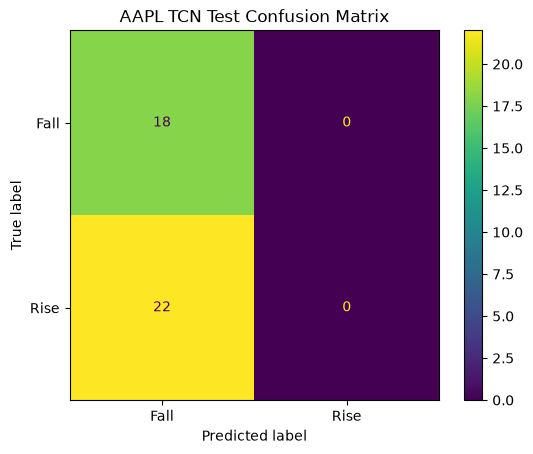

In [17]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Fall",
        "Rise"
    ]
)

disp.plot()

plt.title(
    "AAPL TCN Test Confusion Matrix"
)

plt.show()

In [18]:
train_majority_class = np.bincount(
    y_train
).argmax()

baseline_predictions = np.full(
    len(y_test),
    train_majority_class
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        baseline_predictions
    )
)

print("=" * 60)
print("MAJORITY-CLASS BASELINE")
print("=" * 60)

print(
    "Majority class:",
    "Fall"
    if train_majority_class == 0
    else "Rise"
)

print(
    f"Accuracy:          "
    f"{baseline_accuracy:.4f}"
)

print(
    f"Balanced Accuracy: "
    f"{baseline_balanced_accuracy:.4f}"
)

MAJORITY-CLASS BASELINE
Majority class: Fall
Accuracy:          0.4500
Balanced Accuracy: 0.5000


In [19]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy"
    ],

    "TCN": [
        accuracy,
        balanced_accuracy
    ],

    "Majority Baseline": [
        baseline_accuracy,
        baseline_balanced_accuracy
    ]
})

comparison

,Metric,TCN,Majority Baseline
0,Accuracy,0.45,0.45
1,Balanced Accuracy,0.50,0.50


In [20]:
print(comparison.to_string(index=False))

           Metric  TCN  Majority Baseline
         Accuracy 0.45               0.45
Balanced Accuracy 0.50               0.50


In [21]:
confidence = test_probabilities.max(
    axis=1
)

print(
    pd.Series(
        confidence
    ).describe()
)

count    40.000000
mean      0.955830
std       0.029368
min       0.919404
25%       0.923416
50%       0.956735
75%       0.986637
max       0.991889
dtype: float64


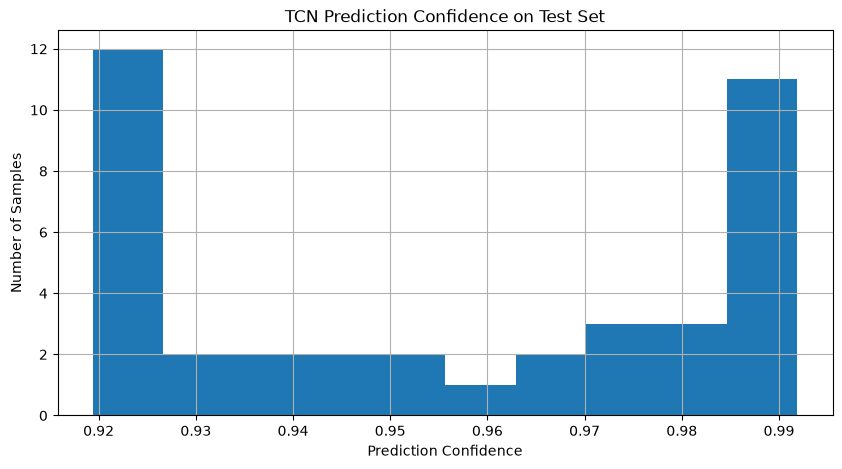

In [22]:
plt.figure(figsize=(10, 5))

plt.hist(
    confidence,
    bins=10
)

plt.xlabel(
    "Prediction Confidence"
)

plt.ylabel(
    "Number of Samples"
)

plt.title(
    "TCN Prediction Confidence on Test Set"
)

plt.grid(True)

plt.show()

In [23]:
results = pd.DataFrame({

    "Date": dates_test,

    "Actual": np.where(
        y_true == 1,
        "Rise",
        "Fall"
    ),

    "Predicted": np.where(
        y_pred == 1,
        "Rise",
        "Fall"
    ),

    "Confidence": confidence
})

results["Correct"] = (
    results["Actual"]
    ==
    results["Predicted"]
)

results.head(10)

,Date,Actual,Predicted,Confidence,Correct
0,2026-06-16,Rise,Fall,0.923547,False
1,2026-06-17,Fall,Fall,0.923023,True
2,2026-06-18,Fall,Fall,0.921712,True
3,2026-06-22,Fall,Fall,0.921385,True
4,2026-06-23,Fall,Fall,0.920603,True
5,2026-06-24,Fall,Fall,0.919794,True
6,2026-06-25,Fall,Fall,0.919404,True
7,2026-06-26,Rise,Fall,0.919593,False
8,2026-06-29,Rise,Fall,0.920087,False
9,2026-06-30,Rise,Fall,0.920176,False


In [24]:
results["Rolling_10_Accuracy"] = (
    results["Correct"]
    .rolling(10)
    .mean()
)

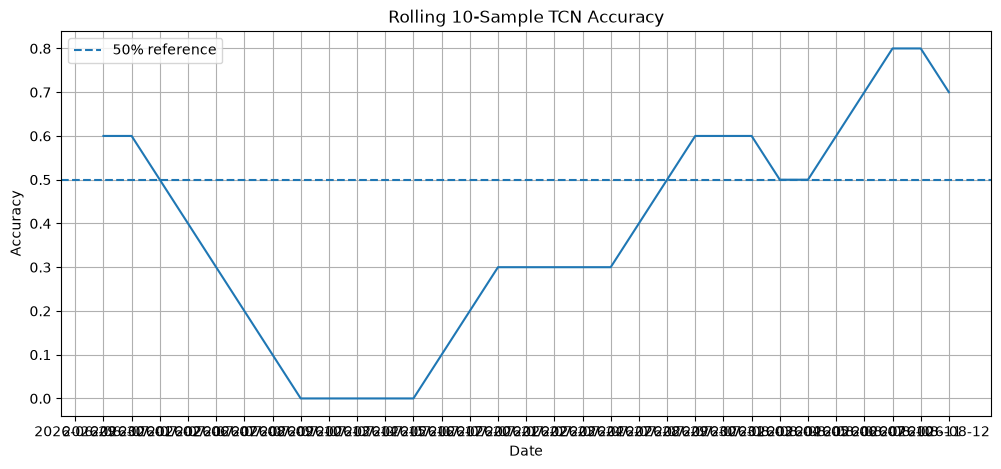

In [25]:
plt.figure(figsize=(12, 5))

plt.plot(
    results["Date"],
    results["Rolling_10_Accuracy"]
)

plt.axhline(
    0.5,
    linestyle="--",
    label="50% reference"
)

plt.xlabel("Date")
plt.ylabel("Accuracy")

plt.title(
    "Rolling 10-Sample TCN Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()

In [26]:
results.to_csv(
    "../data/processed/test_predictions.csv",
    index=False
)

metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1",
        "Baseline Accuracy",
        "Baseline Balanced Accuracy"
    ],

    "Value": [
        accuracy,
        balanced_accuracy,
        precision,
        recall,
        f1,
        baseline_accuracy,
        baseline_balanced_accuracy
    ]
})

metrics.to_csv(
    "../data/processed/test_metrics.csv",
    index=False
)

print("Evaluation results saved.")

Evaluation results saved.


In [27]:
print("=" * 60)
print("FINAL EVALUATION CHECK")
print("=" * 60)

print(f"Test samples:        {len(y_test)}")
print(f"Accuracy:             {accuracy:.4f}")
print(f"Balanced Accuracy:    {balanced_accuracy:.4f}")
print(f"Precision:            {precision:.4f}")
print(f"Recall:               {recall:.4f}")
print(f"F1:                   {f1:.4f}")

print(
    f"\nBaseline Accuracy:    "
    f"{baseline_accuracy:.4f}"
)

print(
    f"Baseline Balanced:    "
    f"{baseline_balanced_accuracy:.4f}"
)

print(
    "\nTCN beats baseline:",
    accuracy > baseline_accuracy
)

FINAL EVALUATION CHECK
Test samples:        40
Accuracy:             0.4500
Balanced Accuracy:    0.5000
Precision:            0.0000
Recall:               0.0000
F1:                   0.0000

Baseline Accuracy:    0.4500
Baseline Balanced:    0.5000

TCN beats baseline: False
